# Validation 07: JADES-like NIRSpec/PRISM spectrum with DSPS + Cue

This is the real-pipeline version of the earlier high-redshift notebook. It simulates a z~10 spectrum using DSPS stellar emission plus Cue nebular emission, applies an approximate NIRSpec/PRISM wavelength range and resolution, and runs a short NUTS fit.

The purpose is not to claim a perfect JADES instrument model. The purpose is to validate that the high-redshift spectral likelihood sees the real DSPS+Cue physics path, including LyC bookkeeping, IGM absorption, observed-frame binning, and mass normalization.

In [1]:
OUTPUT_NAME = 'validation_07_jades_like_dsps_cue_prism'
DEFAULT_WARMUP = '50'
DEFAULT_SAMPLES = '70'

from pathlib import Path
import os
import time
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', message='Trying to unpickle estimator.*')

# Keep the notebook runnable from either the repository root or notebooks/validation.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'composed').exists():
    REPO_ROOT = Path.cwd().parents[1]

OUTPUT_DIR = REPO_ROOT / 'notebooks' / 'outputs' / OUTPUT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Real pipeline resources. The SSP file must be continuum-only; Cue adds nebular emission.
SSP_FILE = Path(os.environ.get(
    'DSPS_CONTINUUM_SSP_FILE',
    REPO_ROOT / 'outputs' / 'experimental_dsps_fsps_clock_diagnostic' / 'fsps_continuum_ssp_data.h5',
))
CUE_DATA_DIR = Path(os.environ.get('CUE_DATA_DIR', '/private/tmp/cue/src/cue/data'))

RUN_NUTS = os.environ.get('COMPOSED_VALIDATE_RUN_NUTS', '1') == '1'
NUM_WARMUP = int(os.environ.get('COMPOSED_VALIDATE_NUM_WARMUP', DEFAULT_WARMUP))
NUM_SAMPLES = int(os.environ.get('COMPOSED_VALIDATE_NUM_SAMPLES', DEFAULT_SAMPLES))
RNG_SEED = int(os.environ.get('COMPOSED_VALIDATE_SEED', '8128'))

print('Repository:', REPO_ROOT)
print('Output directory:', OUTPUT_DIR)
print('SSP file:', SSP_FILE)
print('Cue data dir:', CUE_DATA_DIR)
INIT_NUM_CANDIDATES = int(os.environ.get('COMPOSED_VALIDATE_INIT_NUM_CANDIDATES', '512'))
INIT_NUM_STARTS = int(os.environ.get('COMPOSED_VALIDATE_INIT_NUM_STARTS', '8'))
INIT_OPTIMIZER_STEPS = int(os.environ.get('COMPOSED_VALIDATE_INIT_OPTIMIZER_STEPS', '120'))
INIT_LEARNING_RATE = float(os.environ.get('COMPOSED_VALIDATE_INIT_LEARNING_RATE', '0.03'))

print('Run NUTS:', RUN_NUTS, 'warmup:', NUM_WARMUP, 'samples:', NUM_SAMPLES)
print(
    'QMC+Nadam init:',
    'candidates=', INIT_NUM_CANDIDATES,
    'starts=', INIT_NUM_STARTS,
    'steps=', INIT_OPTIMIZER_STEPS,
    'learning_rate=', INIT_LEARNING_RATE,
)

missing = []
if not SSP_FILE.exists():
    missing.append(f'Missing continuum-only DSPS SSP file: {SSP_FILE}')
if not CUE_DATA_DIR.exists():
    missing.append(f'Missing Cue data directory: {CUE_DATA_DIR}')
if missing:
    raise FileNotFoundError('\n'.join(missing))


Repository: /Users/gregoire/Documents/Sedfitting/CompoSED
Output directory: /Users/gregoire/Documents/Sedfitting/CompoSED/notebooks/outputs/validation_07_jades_like_dsps_cue_prism
SSP file: /Users/gregoire/Documents/Sedfitting/CompoSED/outputs/experimental_dsps_fsps_clock_diagnostic/fsps_continuum_ssp_data.h5
Cue data dir: /Users/gregoire/Documents/Sedfitting/CompoSED/external/cue/src/cue/data
Run NUTS: True warmup: 50 samples: 70
QMC+Nadam init: candidates= 512 starts= 8 steps= 120 learning_rate= 0.03


In [2]:

from dsps import load_ssp_templates

from composed.experimental.jaxcigale import (
    CueJaxPort,
    GaussianPhotometricData,
    GaussianSpectralData,
    GaussianSpectroPhotometricData,
    JaxFilterSet,
    JaxParameterSpace,
    UniformJaxPrior,
    build_jax_sed_model,
    cue_nebular_module,
    delayed_sfh_cosmic_time_module,
    dsps_stellar_module,
    madau_igm_module,
    modified_starburst_attenuation_module,
    pixel_edges_from_centers_numpy,
    redshift_module,
    require_continuum_ssp_path,
    run_numpyro_nuts,
)
from composed.experimental.jaxcigale.core import flat_lcdm_age_gyr_numpy
from composed.experimental.jaxcigale.dependencies import require_jax
from composed.experimental.jaxcigale.spectroscopy import model_spectrum_on_observed_pixels

jax, jnp = require_jax()
print('JAX backend:', jax.default_backend())
print('JAX devices:', jax.devices())
print('JAX scalar dtype:', np.asarray(jnp.asarray(1.0)).dtype)

ssp_data = load_ssp_templates(fn=str(require_continuum_ssp_path(SSP_FILE)))
cue_port = CueJaxPort.from_public_cue_data_dir(CUE_DATA_DIR)
cue_apply = cue_port.make_nebular_apply(line_sigma_a=1.5)
print('Loaded continuum-only SSP and Cue emulator data.')


JAX backend: cpu
JAX devices: [CpuDevice(id=0)]
JAX scalar dtype: float64


Loaded continuum-only SSP and Cue emulator data.


In [3]:

def gaussian_filter_set(filter_specs, n_wave=192):
    """Create simple transparent filters for validation.

    Wavelengths are observed-frame Angstrom. These are not official survey
    curves; they are smooth broadbands used only to exercise the integration.
    """
    names, waves, trans = [], [], []
    for name, center_a, sigma_a in filter_specs:
        w = np.linspace(center_a - 4.0 * sigma_a, center_a + 4.0 * sigma_a, n_wave)
        t = np.exp(-0.5 * ((w - center_a) / sigma_a) ** 2)
        names.append(name)
        waves.append(w)
        trans.append(t)
    return JaxFilterSet.from_curves(names, waves, trans)


def make_dsps_cue_model(rest_wave_a, filters, parameter_space, n_sfh_time=96):
    """Build the real validation model: SFH -> DSPS -> Cue -> dust -> IGM -> redshift."""
    fixed_parameters = {
        'E_BV_old_factor': 0.5,
        'powerlaw_slope': 0.0,
        'uv_bump_amplitude': 0.0,
        'E_BV_nebular': 0.12,
        'gas_logn_h': 2.0,
        'gas_logno': -0.134,
        'gas_logco': -0.134,
        'gas_f_esc': 0.0,
        'gas_f_dust': 0.0,
    }
    modules = [
        delayed_sfh_cosmic_time_module(
            n_time=n_sfh_time,
            min_age_since_onset_gyr=0.02,
            tage_parameter='tage_fraction',
            tage_is_fraction_of_universe_age=True,
        ),
        dsps_stellar_module(ssp_data, z_sun=0.02, separation_age_myr=10.0),
        cue_nebular_module(cue_apply),
        modified_starburst_attenuation_module(
            ebv_young_parameter='E_BV_young',
            ebv_old_factor_parameter='E_BV_old_factor',
            powerlaw_slope_parameter='powerlaw_slope',
            uv_bump_amplitude_parameter='uv_bump_amplitude',
            nebular_ebv_parameter='E_BV_nebular',
            nebular_extinction_law='mw_ccm89',
            nebular_rv=3.1,
        ),
        madau_igm_module(),
        redshift_module(),
    ]
    model = build_jax_sed_model(
        modules,
        rest_wave_a,
        filters,
        parameter_space,
        fixed_parameters=fixed_parameters,
    )
    return model, fixed_parameters


def run_short_nuts(model, data, initial_theta):
    """Run a short validation chain. This checks the pipeline, not final science convergence."""
    start = time.perf_counter()
    result = run_numpyro_nuts(
        model,
        data,
        initial_theta=initial_theta,
        num_warmup=NUM_WARMUP,
        num_samples=NUM_SAMPLES,
        rng_seed=RNG_SEED,
        progress_bar=True,
        transform_bounds=True,
        target_accept_prob=0.82,
        max_tree_depth=9,
        dense_mass=False,
        init_strategy='qmc_nadam',
        init_num_candidates=INIT_NUM_CANDIDATES,
        init_num_starts=INIT_NUM_STARTS,
        init_optimizer_steps=INIT_OPTIMIZER_STEPS,
        init_learning_rate=INIT_LEARNING_RATE,
        init_batch_size=min(512, INIT_NUM_CANDIDATES),
    )
    elapsed = time.perf_counter() - start
    print(f'NUTS elapsed: {elapsed:.1f} s; samples/sec: {NUM_SAMPLES / max(elapsed, 1e-12):.3f}')
    return result, elapsed


def posterior_summary(samples, theta_names, truth):
    rows = []
    for i, name in enumerate(theta_names):
        q16, q50, q84 = np.quantile(samples[:, i], [0.16, 0.50, 0.84])
        rows.append({
            'name': name,
            'truth': float(truth[i]),
            'q16': float(q16),
            'median': float(q50),
            'q84': float(q84),
            'median_minus_truth': float(q50 - truth[i]),
        })
    return rows


def save_summary(path, rows, extra):
    payload = {'posterior_summary': rows, **extra}
    path.write_text(json.dumps(payload, indent=2) + '\n')
    print('Saved summary:', path)


def plot_corner_like(samples, theta_names, truth, title):
    n = samples.shape[1]
    fig, axes = plt.subplots(1, n, figsize=(2.4 * n, 2.4), constrained_layout=True)
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.hist(samples[:, i], bins=24, histtype='stepfilled', alpha=0.65)
        ax.axvline(truth[i], color='k', lw=1.6, label='truth')
        ax.set_title(theta_names[i])
    axes[0].legend(loc='best')
    fig.suptitle(title)
    return fig


In [4]:

dummy_filters = gaussian_filter_set([('f200w_like', 20000.0, 3000.0)])
rest_wave_a = np.geomspace(40.0, 8000.0, 850)

parameter_space = JaxParameterSpace(
    names=('log10_mass', 'z', 'logzsol', 'E_BV_young', 'tau_gyr', 'tage_fraction', 'gas_logu', 'gas_logoh'),
    priors={
        'log10_mass': UniformJaxPrior(7.0, 11.5),
        'z': UniformJaxPrior(6.0, 14.0),
        'logzsol': UniformJaxPrior(-1.8, 0.1),
        'E_BV_young': UniformJaxPrior(0.0, 0.35),
        'tau_gyr': UniformJaxPrior(0.02, 1.2),
        'tage_fraction': UniformJaxPrior(0.05, 0.95),
        'gas_logu': UniformJaxPrior(-3.5, -1.0),
        'gas_logoh': UniformJaxPrior(-1.8, 0.1),
    },
)
model, fixed_parameters = make_dsps_cue_model(rest_wave_a, dummy_filters, parameter_space, n_sfh_time=72)
print('Fitted parameter order:', parameter_space.names)


Fitted parameter order: ('log10_mass', 'z', 'logzsol', 'E_BV_young', 'tau_gyr', 'tage_fraction', 'gas_logu', 'gas_logoh')


## Simulate a PRISM-like observed spectrum

Approximate NIRSpec/PRISM settings used here:

- observed wavelength range: 0.6-5.3 micron (6000-53000 Angstrom);
- resolution: a smooth ramp from R~40 to R~250;
- likelihood comparison: bin-average over pixel edges after model broadening.

In [5]:

rng = np.random.default_rng(123)
truth = parameter_space.from_dict({
    'log10_mass': 8.7,
    'z': 10.0,
    'logzsol': -0.85,
    'E_BV_young': 0.05,
    'tau_gyr': 0.18,
    'tage_fraction': 0.55,
    'gas_logu': -2.0,
    'gas_logoh': -0.9,
})
wave_obs_a = np.geomspace(6000.0, 53000.0, 180)
pixel_edges = pixel_edges_from_centers_numpy(wave_obs_a)
resolving_power = 40.0 + 210.0 * (wave_obs_a - wave_obs_a.min()) / (wave_obs_a.max() - wave_obs_a.min())

state_truth = model.run_modules_mass_scaled(jnp.asarray(truth))
true_flux = np.asarray(model_spectrum_on_observed_pixels(
    state_truth.wave_obs_a,
    state_truth.flux_lambda_cgs,
    jnp.asarray(wave_obs_a),
    pixel_edges,
    resample_mode='bin',
    resolving_power=resolving_power,
))
active_scale = np.nanpercentile(np.abs(true_flux[true_flux > 0]), 60)
sigma = 0.10 * np.maximum(np.abs(true_flux), active_scale)
obs_flux = true_flux + rng.normal(0.0, sigma)
mask = (wave_obs_a > 8000.0) & (wave_obs_a < 52000.0)

spectral_data = GaussianSpectralData(
    wavelength_obs_a=wave_obs_a,
    flux_lambda_cgs=obs_flux,
    sigma_lambda_cgs=sigma,
    mask=mask,
    pixel_edges_obs_a=pixel_edges,
    resample_mode='bin',
    resolving_power=resolving_power,
)

print('Active pixels:', int(mask.sum()), '/', wave_obs_a.size)
print('Age of Universe at truth z [Gyr]:', float(flat_lcdm_age_gyr_numpy(truth[1])))
print('Galaxy age [Gyr]:', float(truth[5] * flat_lcdm_age_gyr_numpy(truth[1])))


Active pixels: 154 / 180
Age of Universe at truth z [Gyr]: 0.47553183842498786
Galaxy age [Gyr]: 0.2615425111337433


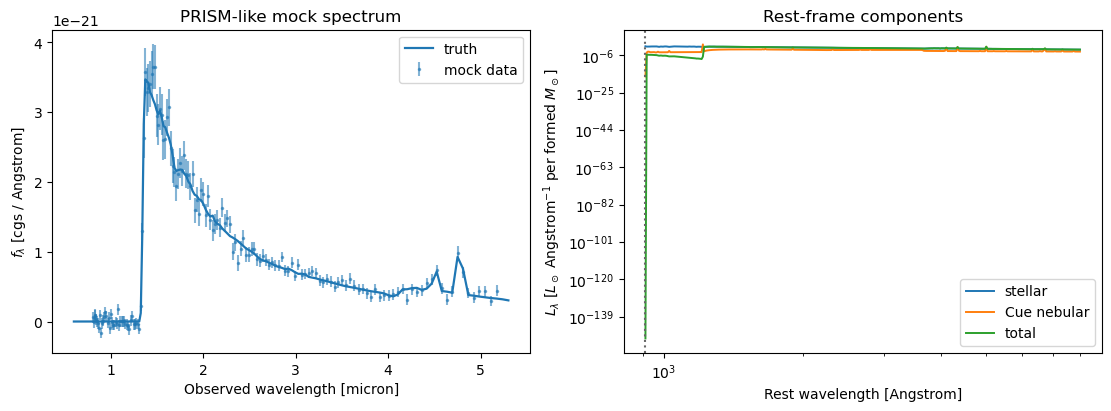

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(wave_obs_a / 1e4, true_flux, color='tab:blue', lw=1.6, label='truth')
axes[0].errorbar(wave_obs_a[mask] / 1e4, obs_flux[mask], yerr=sigma[mask], fmt='.', ms=3, alpha=0.55, label='mock data')
axes[0].set_xlabel('Observed wavelength [micron]')
axes[0].set_ylabel(r'$f_\lambda$ [cgs / Angstrom]')
axes[0].set_title('PRISM-like mock spectrum')
axes[0].legend()

wave_rest = np.asarray(state_truth.wave_rest_a)
components = {
    'stellar': np.asarray(state_truth.stellar_lum_lsun_per_a),
    'Cue nebular': np.asarray(state_truth.nebular_lum_lsun_per_a),
    'total': np.asarray(state_truth.total_lum_lsun_per_a),
}
for label, y in components.items():
    ok = y > 0
    axes[1].loglog(wave_rest[ok], y[ok], lw=1.4, label=label)
axes[1].axvline(912.0, ls=':', color='0.4')
axes[1].set_xlabel('Rest wavelength [Angstrom]')
axes[1].set_ylabel(r'$L_\lambda$ [$L_\odot$ Angstrom$^{-1}$ per formed $M_\odot$]')
axes[1].set_title('Rest-frame components')
axes[1].legend()
fig.savefig(OUTPUT_DIR / 'jades_like_mock_and_components.png', dpi=180)
plt.show()


In [7]:

initial_theta = parameter_space.from_dict({
    'log10_mass': 8.5,
    'z': 9.7,
    'logzsol': -1.1,
    'E_BV_young': 0.08,
    'tau_gyr': 0.25,
    'tage_fraction': 0.45,
    'gas_logu': -2.4,
    'gas_logoh': -1.1,
})

if RUN_NUTS:
    result, nuts_elapsed = run_short_nuts(model, spectral_data, initial_theta)
    samples = np.asarray(result.samples)
    rows = posterior_summary(samples, result.theta_names, truth)
    for row in rows:
        print(f"{row['name']:12s} truth={row['truth']: .4f} median={row['median']: .4f} [{row['q16']: .4f}, {row['q84']: .4f}]")
    save_summary(OUTPUT_DIR / 'nuts_summary.json', rows, {'nuts_elapsed_seconds': nuts_elapsed, 'num_warmup': NUM_WARMUP, 'num_samples': NUM_SAMPLES})
    np.savez(OUTPUT_DIR / 'nuts_samples.npz', samples=samples, theta_names=np.asarray(result.theta_names), truth=truth)
else:
    samples = np.empty((0, parameter_space.ndim))
    print('Skipped NUTS because RUN_NUTS is False.')


/Users/gregoire/miniforge3/envs/composed/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/120 [00:00<?, ?it/s]

warmup:   1%|          | 1/120 [00:05<09:57,  5.02s/it, 1 steps of size 2.25e+00. acc. prob=0.00]

warmup:   4%|▍         | 5/120 [00:12<04:20,  2.26s/it, 511 steps of size 9.05e-04. acc. prob=0.20]

warmup:   5%|▌         | 6/120 [00:19<06:22,  3.35s/it, 511 steps of size 8.56e-04. acc. prob=0.31]

...

sample:  98%|█████████▊| 118/120 [10:48<00:08,  4.01s/it, 511 steps of size 1.34e-02. acc. prob=0.68]

sample:  99%|█████████▉| 119/120 [10:55<00:04,  4.96s/it, 511 steps of size 1.34e-02. acc. prob=0.67]

sample: 100%|██████████| 120/120 [10:59<00:00,  4.55s/it, 255 steps of size 1.34e-02. acc. prob=0.67]

sample: 100%|██████████| 120/120 [10:59<00:00,  5.49s/it, 255 steps of size 1.34e-02. acc. prob=0.67]

NUTS elapsed: 713.9 s; samples/sec: 0.098
log10_mass   truth= 8.7000 median= 8.5191 [ 8.4369,  8.7209]
z            truth= 10.0000 median= 9.9939 [ 9.9884,  10.0000]
logzsol      truth=-0.8500 median=-0.6293 [-0.7741, -0.5586]
E_BV_young   truth= 0.0500 median= 0.0645 [ 0.0559,  0.0790]
tau_gyr      truth= 0.1800 median= 0.4452 [ 0.1669,  0.8753]
tage_fraction truth= 0.5500 median= 0.3842 [ 0.3171,  0.5949]
gas_logu     truth=-2.0000 median=-2.3962 [-3.1613, -1.4832]
gas_logoh    truth=-0.9000 median=-1.2854 [-1.7085, -0.4288]
Saved summary: /Users/gregoire/Documents/Sedfitting/CompoSED/notebooks/outputs/validation_07_jades_like_dsps_cue_prism/nuts_summary.json


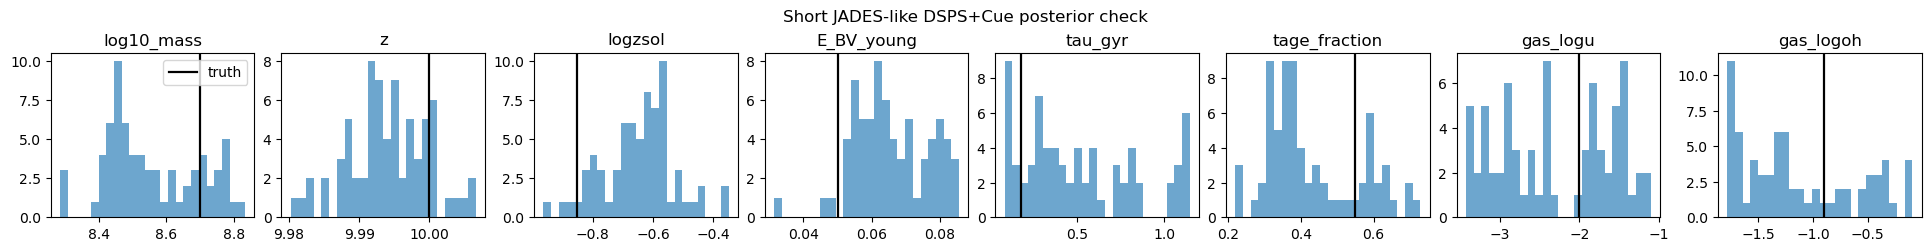

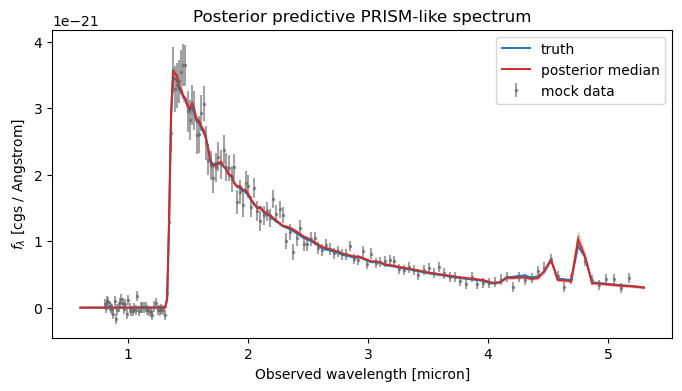

In [8]:

if RUN_NUTS:
    fig = plot_corner_like(samples, result.theta_names, truth, 'Short JADES-like DSPS+Cue posterior check')
    fig.savefig(OUTPUT_DIR / 'posterior_marginals.png', dpi=180)
    plt.show()

    take = np.linspace(0, len(samples) - 1, min(20, len(samples))).astype(int)
    pred = []
    for theta in samples[take]:
        state = model.run_modules_mass_scaled(jnp.asarray(theta))
        pred.append(np.asarray(model_spectrum_on_observed_pixels(
            state.wave_obs_a, state.flux_lambda_cgs, jnp.asarray(wave_obs_a), pixel_edges,
            resample_mode='bin', resolving_power=resolving_power,
        )))
    pred = np.asarray(pred)
    med = np.median(pred, axis=0)
    lo, hi = np.quantile(pred, [0.16, 0.84], axis=0)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.errorbar(wave_obs_a[mask] / 1e4, obs_flux[mask], yerr=sigma[mask], fmt='.', ms=3, color='0.4', alpha=0.6, label='mock data')
    ax.plot(wave_obs_a / 1e4, true_flux, color='tab:blue', lw=1.4, label='truth')
    ax.plot(wave_obs_a / 1e4, med, color='tab:red', lw=1.4, label='posterior median')
    ax.fill_between(wave_obs_a / 1e4, lo, hi, color='tab:red', alpha=0.2)
    ax.set_xlabel('Observed wavelength [micron]')
    ax.set_ylabel(r'$f_\lambda$ [cgs / Angstrom]')
    ax.set_title('Posterior predictive PRISM-like spectrum')
    ax.legend()
    fig.savefig(OUTPUT_DIR / 'posterior_predictive_spectrum.png', dpi=180)
    plt.show()
